In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

In [4]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [5]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

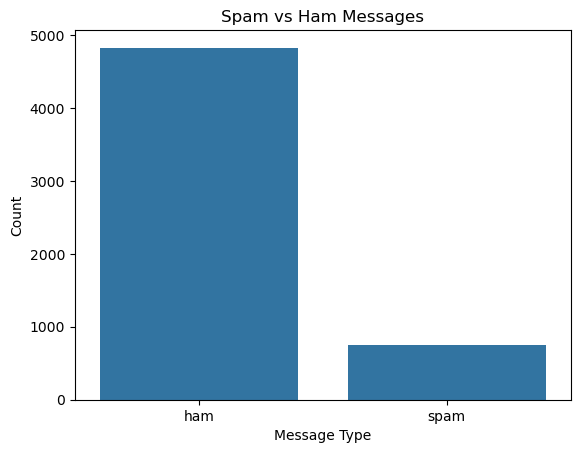

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=df)

plt.title('Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

In [9]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [10]:
df.duplicated().sum()

403

In [11]:
df = df.drop_duplicates(keep='first')

print("New shape:", df.shape)

New shape: (5169, 2)


In [12]:
df.duplicated().sum()

0

In [13]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df['label'].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

In [15]:
df = df.drop_duplicates(keep='first')

In [16]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})


In [17]:
df['label'].value_counts()

Series([], Name: count, dtype: int64)

In [18]:
import pandas as pd

# Reload original dataset
df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only required columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Remove duplicate rows
df = df.drop_duplicates(keep='first')

# Convert labels
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

print("Shape:", df.shape)
print("\nLabel counts:")
print(df['label'].value_counts())

Shape: (5169, 2)

Label counts:
label
0    4516
1     653
Name: count, dtype: int64


In [19]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [21]:
sample = df['message'].iloc[2]

print("Original:")
print(sample)

print("\nCleaned:")
print(clean_text(sample))

Original:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Cleaned:
free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questionstd txt ratetcs apply overs


In [22]:
df['clean_message'] = df['message'].apply(clean_text)

In [23]:
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [24]:
from sklearn.model_selection import train_test_split

X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4135, 7370)
Testing shape: (1034, 7370)


In [26]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [27]:
y_pred_nb = nb_model.predict(X_test_tfidf)

y_pred_nb[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [28]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred_nb)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=['Ham', 'Spam']
))

Accuracy: 0.9477756286266924

Classification Report:
              precision    recall  f1-score   support

         Ham       0.94      1.00      0.97       903
        Spam       1.00      0.59      0.74       131

    accuracy                           0.95      1034
   macro avg       0.97      0.79      0.86      1034
weighted avg       0.95      0.95      0.94      1034



[[903   0]
 [ 54  77]]


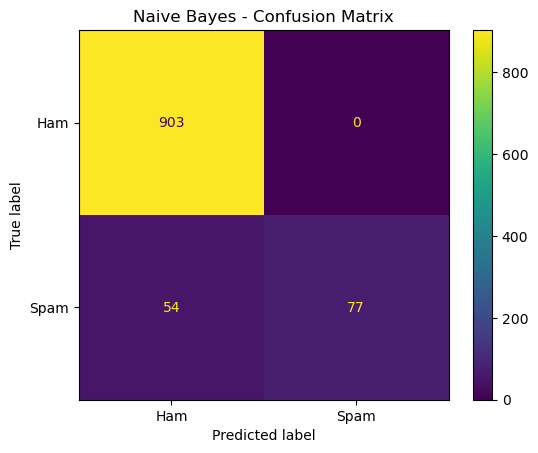

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [31]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [32]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Ham', 'Spam']
    )
)

Accuracy: 0.9632495164410058

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.72      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.96      0.96      0.96      1034



In [33]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

print("Linear SVM trained successfully!")

Linear SVM trained successfully!


In [34]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=['Ham', 'Spam']
    )
)

Accuracy: 0.9806576402321083

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.97      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



[[900   3]
 [ 17 114]]


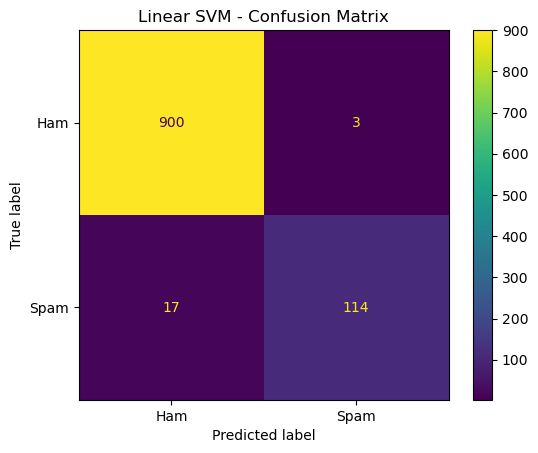

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=['Ham', 'Spam']
)

disp.plot()
plt.title("Linear SVM - Confusion Matrix")
plt.show()

In [37]:
models = {
    'Naive Bayes': y_pred_nb,
    'Logistic Regression': y_pred_lr,
    'Linear SVM': y_pred_svm
}

results = []

for name, predictions in models.items():
    report = classification_report(
        y_test,
        predictions,
        output_dict=True
    )
    
    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Spam Precision': report['1']['precision'],
        'Spam Recall': report['1']['recall'],
        'Spam F1': report['1']['f1-score']
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Spam Precision,Spam Recall,Spam F1
0,Naive Bayes,0.947776,1.000000,0.587786,0.740385
1,Logistic Regression,0.963250,0.989474,0.717557,0.831858
2,Linear SVM,0.980658,0.974359,0.870229,0.919355


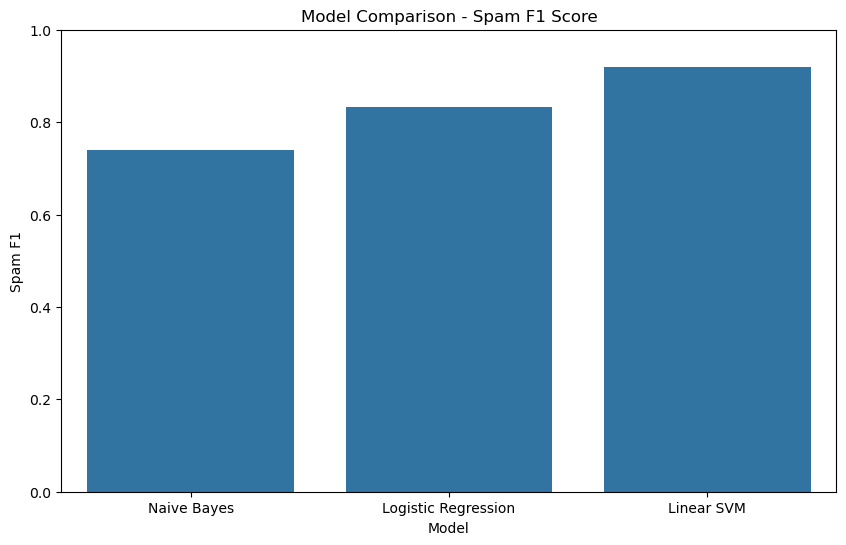

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Spam F1'
)

plt.title('Model Comparison - Spam F1 Score')
plt.ylim(0, 1)
plt.show()

In [39]:
import joblib

joblib.dump(svm_model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [40]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'SMS_Spam_Classifier.ipynb', 'spam.csv', 'spam_model.pkl', 'tfidf_vectorizer.pkl']


In [41]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_svm = CalibratedClassifierCV(
    svm_model,
    cv=5
)

calibrated_svm.fit(X_train_tfidf, y_train)

print("Calibrated SVM trained successfully!")

Calibrated SVM trained successfully!


In [42]:
y_pred_calibrated = calibrated_svm.predict(X_test_tfidf)

y_prob = calibrated_svm.predict_proba(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_calibrated))

Accuracy: 0.9796905222437138


In [43]:
sample_index = 0

print("Actual:", "Spam" if y_test.iloc[sample_index] == 1 else "Ham")
print("Predicted:", "Spam" if y_pred_calibrated[sample_index] == 1 else "Ham")
print("Confidence:", max(y_prob[sample_index]) * 100)

Actual: Ham
Predicted: Ham
Confidence: 99.77845551477718


In [44]:
import joblib

joblib.dump(calibrated_svm, "spam_calibrated_model.pkl")

print("Calibrated model saved successfully!")

Calibrated model saved successfully!


In [45]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'SMS_Spam_Classifier.ipynb', 'spam.csv', 'spam_calibrated_model.pkl', 'spam_model.pkl', 'tfidf_vectorizer.pkl']
